# Polymarket BTC — 20 Estrategias Rule-Based · v2

Notebook sin ML. 20 estrategias basadas en reglas duras.

### Restricciones
- **1 trade por mercado** (máximo)
- **No operar en el último X% del mercado** (`MAX_PROGRESS`) — evitar cuasi-leakage
- **Objetivo: maximizar ROI (€)**, no Win Rate

### Estrategias 1–10 (originales)

| # | Nombre | Lógica |
|---|--------|--------|
| 1 | Momentum BTC | `btc_return_since_open > 0` → UP |
| 2 | MA Crossover | `ret_1m > ret_5m` → UP |
| 3 | Premium Follow | `mkt_premium > 0` → seguir mercado |
| 4 | Divergence Reversion | BTC vs mercado → mean reversion |
| 5 | Book Imbalance | Desequilibrio bid/ask |
| 6 | Volume + Momentum | Alto volumen confirma dirección |
| 7 | Low Vol Momentum | Momentum fiable en baja vol |
| 8 | Streak Contrarian | Revertir rachas largas |
| 9 | Consensus (5 señales) | ≥3 señales coinciden |
| 10 | Cheap Ask + Momentum | Ask barato + dirección |

### Estrategias 11–20 (nuevas)

| # | Nombre | Lógica |
|---|--------|--------|
| 11 | Strong Momentum | Solo operar si `btc_return_since_open` grande (> p75) |
| 12 | Triple MA Confirm | ret_1m, ret_3m, ret_5m todos misma dirección |
| 13 | Premium Fade | Ir contra mkt_premium extremo (contrarian) |
| 14 | Vol Breakout | Volatilidad sube (vol_ratio > 1.2) + momentum |
| 15 | Surprise Fade | Mercados con sorpresas recientes → ir contra tendencia |
| 16 | Divergence + Volume | Divergencia BTC–poly + volumen alto |
| 17 | Early Bird Momentum | Solo operar muy temprano (progress < 0.25) + momentum |
| 18 | Aggressive Consensus | 7 señales, ≥5 coinciden |
| 19 | Cheap Ask Contrarian | Ask muy barato (< 0.40) + señal contrarian de rachas |
| 20 | Momentum + Book + Premium | Triple confirmación: momentum + book + premium |

---
## 1 · Imports y Configuración

In [24]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# =============================================================================
# PARÁMETROS GLOBALES
# =============================================================================
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    TRAIN_FRAC   = 0.40,
    VAL_FRAC     = 0.15,

    STAKE        = 10.0,
    INIT_CAPITAL = 1_000.0,

    # ── Ventana de entrada (market_progress) ─────────────────────────────
    ENTRY_LO     = 0.10,   # no operar antes del 10%
    ENTRY_HI     = 0.60,   # no operar después del 60% (queda ≥40% hasta cierre)
    # → MAX_PROGRESS = 1.0 - ENTRY_HI  → queda 40% mínimo para cierre
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<22} = {v}")
print(f"\n  → Al mercado le queda al menos {(1.0 - CFG['ENTRY_HI']):.0%} hasta cierre")
print(f"  → 1 trade por mercado (máximo)")
print(f"  → Objetivo: maximizar ROI")

Configuración:
  DATA_PATH              = ../dataset_with_resolution.csv
  TRAIN_FRAC             = 0.4
  VAL_FRAC               = 0.15
  STAKE                  = 10.0
  INIT_CAPITAL           = 1000.0
  ENTRY_LO               = 0.1
  ENTRY_HI               = 0.6

  → Al mercado le queda al menos 40% hasta cierre
  → 1 trade por mercado (máximo)
  → Objetivo: maximizar ROI


---
## 2 · Carga y Limpieza

In [25]:
# =============================================================================
# 2. CARGA Y LIMPIEZA
# =============================================================================
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')

df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
    print(f"Eliminados {len(bad)} mercados con resolución inconsistente.")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Mercados: {df['market_slug'].nunique():,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Resoluciones: {df['resolution'].value_counts().to_dict()}")

Dataset: 142,717 filas × 66 columnas
Mercados: 1,485
Rango: 2026-03-19 16:15:55.759706+00:00  →  2026-03-24 19:58:42.061395+00:00
Resoluciones: {'up': 71869, 'down': 70848}


In [26]:
# =============================================================================
# 2b. TIMING FEATURES
# =============================================================================
_times = (
    df.groupby('market_slug')['timestamp']
    .agg(market_open='min', market_close='max')
    .reset_index()
)
df = df.merge(_times, on='market_slug', how='left')

df['market_duration_s'] = (
    df['market_close'] - df['market_open']
).dt.total_seconds().clip(lower=1)

df['seconds_from_open'] = (
    df['timestamp'] - df['market_open']
).dt.total_seconds().clip(lower=0)

df['seconds_to_close'] = (
    df['market_close'] - df['timestamp']
).dt.total_seconds().clip(lower=0)

print(f"Timing features añadidos. Duración media: "
      f"{df['market_duration_s'].mean():.1f} s  "
      f"(mediana: {df['market_duration_s'].median():.1f} s)")

Timing features añadidos. Duración media: 296.7 s  (mediana: 296.8 s)


---
## 3 · Feature Engineering

In [27]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

fe['vol_ratio'] = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)
fe['mkt_premium'] = fe['up_ask_p_1'] - fe['down_ask_p_1']

fe['up_book_imbalance'] = (
    (fe['up_bid_s_1'] - fe['up_ask_s_1']) /
    (fe['up_bid_s_1'] + fe['up_ask_s_1'] + 1e-9)
)
fe['down_book_imbalance'] = (
    (fe['down_bid_s_1'] - fe['down_ask_s_1']) /
    (fe['down_bid_s_1'] + fe['down_ask_s_1'] + 1e-9)
)

fe['btc_poly_divergence'] = fe['btc_return_since_open'] - fe['mkt_premium']

# ── Rachas (sin look-ahead) ──────────────────────────────────────────────────
STREAK_WINDOW = 5

_res = (
    fe.groupby('market_slug').agg(
        resolution=('resolution', 'first'),
        close_ts=('market_close', 'first'),
        last_up_ask=('up_ask_p_1', 'last'),
    )
    .sort_values('close_ts')
    .reset_index()
)
_res['res_up'] = (_res['resolution'].str.lower() == 'up').astype(int)

_res['recent_up_pct_5'] = (
    _res['res_up'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

def compute_streak(series):
    shifted = series.shift(1)
    streaks = []
    for i in range(len(shifted)):
        if pd.isna(shifted.iloc[i]):
            streaks.append(0); continue
        streak = 0; last_val = shifted.iloc[i]
        for j in range(i, -1, -1):
            if pd.isna(shifted.iloc[j]) or shifted.iloc[j] != last_val: break
            streak += 1
        streaks.append(streak if last_val == 1 else -streak)
    return streaks

_res['recent_streak'] = compute_streak(_res['res_up'])

_res['was_surprise'] = (
    ((_res['res_up'] == 1) & (_res['last_up_ask'] < 0.50)) |
    ((_res['res_up'] == 0) & (_res['last_up_ask'] >= 0.50))
).astype(int)

_res['recent_mkt_surprise_5'] = (
    _res['was_surprise'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

_streak_map = _res.set_index('market_slug')[[
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5'
]]
fe = fe.merge(_streak_map, left_on='market_slug', right_index=True, how='left')
fe['recent_up_pct_5']       = fe['recent_up_pct_5'].fillna(0.5)
fe['recent_streak']         = fe['recent_streak'].fillna(0)
fe['recent_mkt_surprise_5'] = fe['recent_mkt_surprise_5'].fillna(0.5)

# ── Target ───────────────────────────────────────────────────────────────────
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

print(f"Features construidas. Dataset: {len(fe):,} filas")

Features construidas. Dataset: 142,717 filas


---
## 4 · Split Temporal por Mercado

In [28]:
# =============================================================================
# 4. SPLIT TEMPORAL POR MERCADO
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
val_m   = market_order[n_train : n_train + n_val]
test_m  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_m)].copy()
te = fe[fe['market_slug'].isin(test_m)].copy()

assert tr['timestamp'].max() < te['timestamp'].min(), "LEAKAGE train/test"
print("Sin leakage temporal confirmado.")

print(f"\n{'Split':<12} {'Mercados':>9} {'Filas':>8} {'UP%':>6}")
print("-" * 38)
for name, split in [('Train', tr), ('Test', te)]:
    y_pct = (split['resolution'].str.lower() == 'up').mean()
    print(f"{name:<12} {split['market_slug'].nunique():>9,} {len(split):>8,} {y_pct:>6.1%}")

Sin leakage temporal confirmado.

Split         Mercados    Filas    UP%
--------------------------------------
Train              594   57,044  49.9%
Test               669   64,241  51.1%


---
## 5 · Calibración de Umbrales (Train)

In [29]:
# =============================================================================
# 5. CALIBRACIÓN DE UMBRALES EN TRAIN
# =============================================================================
tr_window = tr[
    (tr['market_progress'] >= CFG['ENTRY_LO']) &
    (tr['market_progress'] <= CFG['ENTRY_HI'])
].copy()

print(f"Train en ventana de operación: {len(tr_window):,} snapshots")

# ── Percentiles clave ─────────────────────────────────────────────────────────
RET_OPEN_P75 = tr_window['btc_return_since_open'].quantile(0.75)
RET_OPEN_P25 = tr_window['btc_return_since_open'].quantile(0.25)
VOL_P75      = tr_window['volatility_5m'].quantile(0.75)
VOL_P25      = tr_window['volatility_5m'].quantile(0.25)
VOLUME_P75   = tr_window['volume_1m'].quantile(0.75)
VOLUME_P50   = tr_window['volume_1m'].quantile(0.50)
PREM_P90     = tr_window['mkt_premium'].quantile(0.90)
PREM_P10     = tr_window['mkt_premium'].quantile(0.10)
DIV_P75      = tr_window['btc_poly_divergence'].quantile(0.75)
DIV_P25      = tr_window['btc_poly_divergence'].quantile(0.25)

print(f"\nUmbrales calibrados (percentiles del train):")
for name, val in [
    ('RET_OPEN_P75', RET_OPEN_P75), ('RET_OPEN_P25', RET_OPEN_P25),
    ('VOL_P75', VOL_P75), ('VOL_P25', VOL_P25),
    ('VOLUME_P75', VOLUME_P75), ('VOLUME_P50', VOLUME_P50),
    ('PREM_P90', PREM_P90), ('PREM_P10', PREM_P10),
    ('DIV_P75', DIV_P75), ('DIV_P25', DIV_P25),
]:
    print(f"  {name:<16} = {val:+.6f}")

Train en ventana de operación: 28,916 snapshots

Umbrales calibrados (percentiles del train):
  RET_OPEN_P75     = +0.000334
  RET_OPEN_P25     = -0.000391
  VOL_P75          = +0.000592
  VOL_P25          = +0.000244
  VOLUME_P75       = +12.200080
  VOLUME_P50       = +6.145010
  PREM_P90         = +0.590000
  PREM_P10         = -0.630000
  DIV_P75          = +0.349620
  DIV_P25          = -0.329404


---
## 6 · Definición de las 20 Estrategias

In [30]:
# =============================================================================
# 6. DEFINICIÓN DE LAS 20 ESTRATEGIAS
# =============================================================================
#
# Cada estrategia: signal_fn(row) → 'UP', 'DOWN' o None
#
# REGLA DE ORO: el backtest ya filtra por ventana [ENTRY_LO, ENTRY_HI]
#   y garantiza 1 trade/mercado. La función solo decide dirección.
#
# OBJETIVO: maximizar ROI, no WR.  Eso implica:
#   - Mejor un trade con ask barato (alto pago) que muchos con ask alto
#   - Mejor pocas señales fuertes que muchas débiles
# =============================================================================


# ═════════════════════════════════════════════════════════════════════════════
# ESTRATEGIAS 1-10 (originales)
# ═════════════════════════════════════════════════════════════════════════════

# 1. Momentum BTC
def strat_momentum(row):
    ret = row.get('btc_return_since_open', 0)
    if pd.isna(ret) or ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# 2. MA Crossover (ret_1m > ret_5m)
def strat_ma_crossover(row):
    r1 = row.get('ret_1m', np.nan)
    r5 = row.get('ret_5m', np.nan)
    if pd.isna(r1) or pd.isna(r5):
        return None
    if r1 > r5:
        return 'UP'
    elif r1 < r5:
        return 'DOWN'
    return None


# 3. Market Premium Follow
def strat_premium_follow(row):
    prem = row.get('mkt_premium', np.nan)
    if pd.isna(prem) or abs(prem) < 0.02:
        return None
    return 'UP' if prem > 0 else 'DOWN'


# 4. Divergence Mean Reversion
def strat_divergence(row):
    div = row.get('btc_poly_divergence', np.nan)
    if pd.isna(div):
        return None
    threshold = 0.002
    if div > threshold:
        return 'UP'
    elif div < -threshold:
        return 'DOWN'
    return None


# 5. Book Imbalance
def strat_book_imbalance(row):
    up_imb   = row.get('up_book_imbalance', np.nan)
    down_imb = row.get('down_book_imbalance', np.nan)
    if pd.isna(up_imb) or pd.isna(down_imb):
        return None
    threshold = 0.15
    if up_imb > threshold and down_imb < -threshold:
        return 'UP'
    elif down_imb > threshold and up_imb < -threshold:
        return 'DOWN'
    return None


# 6. Volume Spike + Momentum
def strat_volume_momentum(row):
    vol = row.get('volume_1m', np.nan)
    ret = row.get('ret_1m', np.nan)
    if pd.isna(vol) or pd.isna(ret):
        return None
    if vol < VOLUME_P75:
        return None
    if ret > 0:
        return 'UP'
    elif ret < 0:
        return 'DOWN'
    return None


# 7. Low Vol Momentum
def strat_lowvol_momentum(row):
    vol5 = row.get('volatility_5m', np.nan)
    ret  = row.get('btc_return_since_open', np.nan)
    if pd.isna(vol5) or pd.isna(ret):
        return None
    if vol5 > VOL_P75:
        return None
    if ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# 8. Streak Contrarian
def strat_streak_contrarian(row):
    streak = row.get('recent_streak', np.nan)
    if pd.isna(streak):
        return None
    threshold = 3
    if streak >= threshold:
        return 'DOWN'
    elif streak <= -threshold:
        return 'UP'
    return None


# 9. Multi-Signal Consensus (5 señales, ≥3)
def strat_consensus(row):
    up, dn = 0, 0
    for val, col in [
        (row.get('btc_return_since_open', np.nan), None),
        (row.get('mkt_premium', np.nan), None),
        (row.get('ret_1m', np.nan), None),
        (row.get('ret_5m', np.nan), None),
        (row.get('btc_poly_divergence', np.nan), None),
    ]:
        if not pd.isna(val) and val != 0:
            if val > 0: up += 1
            else: dn += 1
    if up >= 3: return 'UP'
    if dn >= 3: return 'DOWN'
    return None


# 10. Cheap Ask + Momentum
def strat_cheap_momentum(row):
    ret      = row.get('btc_return_since_open', np.nan)
    up_ask   = row.get('up_ask_p_1', np.nan)
    down_ask = row.get('down_ask_p_1', np.nan)
    if pd.isna(ret) or pd.isna(up_ask) or pd.isna(down_ask):
        return None
    max_ask = 0.55
    if ret > 0 and up_ask <= max_ask:
        return 'UP'
    elif ret < 0 and down_ask <= max_ask:
        return 'DOWN'
    return None


# ═════════════════════════════════════════════════════════════════════════════
# ESTRATEGIAS 11-20 (nuevas)
# ═════════════════════════════════════════════════════════════════════════════


# 11. Strong Momentum — Solo señales fuertes (retorno > P75)
#     Menos trades pero más convicción → mejor ROI por trade
def strat_strong_momentum(row):
    ret = row.get('btc_return_since_open', np.nan)
    if pd.isna(ret):
        return None
    if ret > RET_OPEN_P75:
        return 'UP'
    elif ret < RET_OPEN_P25:
        return 'DOWN'
    return None


# 12. Triple MA Confirm — ret_1m, ret_3m, ret_5m TODOS misma dirección
#     Triple confirmación = señal de alta convicción
def strat_triple_ma(row):
    r1 = row.get('ret_1m', np.nan)
    r3 = row.get('ret_3m', np.nan)
    r5 = row.get('ret_5m', np.nan)
    if pd.isna(r1) or pd.isna(r3) or pd.isna(r5):
        return None
    if r1 > 0 and r3 > 0 and r5 > 0:
        return 'UP'
    elif r1 < 0 and r3 < 0 and r5 < 0:
        return 'DOWN'
    return None


# 13. Premium Fade — Ir CONTRA premium extremo (contrarian)
#     Si el mercado está muy cargado a un lado → revertir
def strat_premium_fade(row):
    prem = row.get('mkt_premium', np.nan)
    if pd.isna(prem):
        return None
    if prem > PREM_P90:
        return 'DOWN'  # mercado muy UP → ir contra
    elif prem < PREM_P10:
        return 'UP'    # mercado muy DOWN → ir contra
    return None


# 14. Vol Breakout — Volatilidad acelerando (vol_ratio > 1.2) + momentum
#     Cuando la vol sube → breakout, seguir la dirección
def strat_vol_breakout(row):
    vr  = row.get('vol_ratio', np.nan)
    ret = row.get('btc_return_since_open', np.nan)
    if pd.isna(vr) or pd.isna(ret):
        return None
    if vr < 1.2:  # vol_3m/vol_5m < 1.2 → no hay breakout
        return None
    if ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# 15. Surprise Fade — Si hubo sorpresas recientes → ir contra tendencia
#     Mercados con muchas sorpresas = reversión inminente
def strat_surprise_fade(row):
    surp = row.get('recent_mkt_surprise_5', np.nan)
    pct  = row.get('recent_up_pct_5', np.nan)
    if pd.isna(surp) or pd.isna(pct):
        return None
    if surp < 0.3:  # pocas sorpresas → no hay señal
        return None
    # Si muchas sorpresas + tendencia UP → ir DOWN
    if pct > 0.6:
        return 'DOWN'
    elif pct < 0.4:
        return 'UP'
    return None


# 16. Divergence + Volume — Divergencia grande + volumen alto
#     Divergencia confirmada por volumen = más fiable
def strat_divergence_volume(row):
    div = row.get('btc_poly_divergence', np.nan)
    vol = row.get('volume_1m', np.nan)
    if pd.isna(div) or pd.isna(vol):
        return None
    if vol < VOLUME_P50:  # necesitamos al menos volumen mediano
        return None
    if div > DIV_P75:
        return 'UP'
    elif div < DIV_P25:
        return 'DOWN'
    return None


# 17. Early Bird Momentum — Solo operar MUY temprano (progress < 0.25)
#     Entrar pronto = ask más barato generalmente = mejor ROI si aciertas
def strat_early_bird(row):
    prog = row.get('market_progress', np.nan)
    ret  = row.get('btc_return_since_open', np.nan)
    if pd.isna(prog) or pd.isna(ret):
        return None
    if prog > 0.25:  # solo queremos entradas muy tempranas
        return None
    if ret == 0:
        return None
    return 'UP' if ret > 0 else 'DOWN'


# 18. Aggressive Consensus — 7 señales, ≥5 coinciden
#     Más señales = filtro más estricto → solo las mejores oportunidades
def strat_aggressive_consensus(row):
    up, dn = 0, 0
    signals = [
        row.get('btc_return_since_open', np.nan),
        row.get('mkt_premium', np.nan),
        row.get('ret_1m', np.nan),
        row.get('ret_3m', np.nan),
        row.get('ret_5m', np.nan),
        row.get('ret_10m', np.nan),
        row.get('btc_poly_divergence', np.nan),
    ]
    for val in signals:
        if not pd.isna(val) and val != 0:
            if val > 0: up += 1
            else: dn += 1
    if up >= 5: return 'UP'
    if dn >= 5: return 'DOWN'
    return None


# 19. Cheap Ask Contrarian — Ask MUY barato (< 0.40) + racha contraria
#     Pago potencial alto (>2.5x) + señal contrarian = alto ROI
def strat_cheap_contrarian(row):
    streak   = row.get('recent_streak', np.nan)
    up_ask   = row.get('up_ask_p_1', np.nan)
    down_ask = row.get('down_ask_p_1', np.nan)
    if pd.isna(streak) or pd.isna(up_ask) or pd.isna(down_ask):
        return None
    max_ask = 0.40  # ask muy barato → pago alto
    # Racha de downs + UP barato
    if streak <= -2 and up_ask <= max_ask:
        return 'UP'
    # Racha de ups + DOWN barato
    elif streak >= 2 and down_ask <= max_ask:
        return 'DOWN'
    return None


# 20. Triple Confirm: Momentum + Book + Premium
#     Las 3 fuentes (BTC, libro, mercado) deben coincidir
def strat_triple_confirm(row):
    ret    = row.get('btc_return_since_open', np.nan)
    prem   = row.get('mkt_premium', np.nan)
    up_imb = row.get('up_book_imbalance', np.nan)
    dn_imb = row.get('down_book_imbalance', np.nan)
    if pd.isna(ret) or pd.isna(prem) or pd.isna(up_imb) or pd.isna(dn_imb):
        return None
    # Todo apunta UP: BTC sube + mercado UP + book imbalance UP
    if ret > 0 and prem > 0.01 and up_imb > 0:
        return 'UP'
    elif ret < 0 and prem < -0.01 and dn_imb > 0:
        return 'DOWN'
    return None


# ═════════════════════════════════════════════════════════════════════════════
# REGISTRO
# ═════════════════════════════════════════════════════════════════════════════
STRATEGIES = [
    ('01_Momentum_BTC',        strat_momentum),
    ('02_MA_Crossover',        strat_ma_crossover),
    ('03_Premium_Follow',      strat_premium_follow),
    ('04_Divergence_Revert',   strat_divergence),
    ('05_Book_Imbalance',      strat_book_imbalance),
    ('06_Volume_Momentum',     strat_volume_momentum),
    ('07_LowVol_Momentum',     strat_lowvol_momentum),
    ('08_Streak_Contrarian',   strat_streak_contrarian),
    ('09_Consensus_5of3',      strat_consensus),
    ('10_Cheap_Momentum',      strat_cheap_momentum),
    ('11_Strong_Momentum',     strat_strong_momentum),
    ('12_Triple_MA',           strat_triple_ma),
    ('13_Premium_Fade',        strat_premium_fade),
    ('14_Vol_Breakout',        strat_vol_breakout),
    ('15_Surprise_Fade',       strat_surprise_fade),
    ('16_Divergence_Volume',   strat_divergence_volume),
    ('17_Early_Bird',          strat_early_bird),
    ('18_Aggr_Consensus_7of5', strat_aggressive_consensus),
    ('19_Cheap_Contrarian',    strat_cheap_contrarian),
    ('20_Triple_Confirm',      strat_triple_confirm),
]

print(f"Estrategias registradas: {len(STRATEGIES)}")
for name, _ in STRATEGIES:
    tag = '(nueva)' if int(name[:2]) > 10 else ''
    print(f"  • {name} {tag}")

Estrategias registradas: 20
  • 01_Momentum_BTC 
  • 02_MA_Crossover 
  • 03_Premium_Follow 
  • 04_Divergence_Revert 
  • 05_Book_Imbalance 
  • 06_Volume_Momentum 
  • 07_LowVol_Momentum 
  • 08_Streak_Contrarian 
  • 09_Consensus_5of3 
  • 10_Cheap_Momentum 
  • 11_Strong_Momentum (nueva)
  • 12_Triple_MA (nueva)
  • 13_Premium_Fade (nueva)
  • 14_Vol_Breakout (nueva)
  • 15_Surprise_Fade (nueva)
  • 16_Divergence_Volume (nueva)
  • 17_Early_Bird (nueva)
  • 18_Aggr_Consensus_7of5 (nueva)
  • 19_Cheap_Contrarian (nueva)
  • 20_Triple_Confirm (nueva)


---
## 7 · Motor de Backtest

In [31]:
# =============================================================================
# 7. MOTOR DE BACKTEST — RULE-BASED
# =============================================================================
#
# Restricciones implementadas:
#   1) 1 trade por mercado (máximo)
#   2) Solo operar en ventana [ENTRY_LO, ENTRY_HI]
#      → al mercado le queda (1 - ENTRY_HI) hasta cierre
#   3) Hold hasta resolución (sin exit anticipado)
#   4) Objetivo: maximizar ROI, no WR
# =============================================================================


def find_entry_rule(market_snaps, cfg, signal_fn):
    """
    Busca el primer snapshot dentro de [ENTRY_LO, ENTRY_HI] donde
    la señal da dirección. 1 trade/mercado máximo.
    """
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']
    window = (
        market_snaps[
            (market_snaps['market_progress'] >= lo) &
            (market_snaps['market_progress'] <= hi)
        ]
        .sort_values('timestamp')
    )
    if window.empty:
        return None, None

    for _, row in window.iterrows():
        direction = signal_fn(row)
        if direction is None:
            continue
        ask_col = 'up_ask_p_1' if direction == 'UP' else 'down_ask_p_1'
        ask = float(row[ask_col])
        if pd.isna(ask) or ask <= 0 or ask >= 1.0:
            continue
        return row, direction

    return None, None


def run_backtest_rule(snapshot_df, cfg, signal_fn):
    """
    Backtest completo para una estrategia rule-based.
    """
    STAKE = cfg['STAKE']
    trades = []

    for mkt, grp in snapshot_df.groupby('market_slug'):
        snaps = grp.sort_values('timestamp').reset_index(drop=True)

        entry_row, direction = find_entry_rule(snaps, cfg, signal_fn)
        if entry_row is None:
            continue

        entry_ask = (
            entry_row['up_ask_p_1'] if direction == 'UP'
            else entry_row['down_ask_p_1']
        )
        if entry_ask <= 0 or np.isnan(entry_ask):
            continue

        resolution = snaps['resolution'].iloc[0]
        actual_up  = (resolution.lower() == 'up')
        won = (actual_up if direction == 'UP' else not actual_up)
        win_net  = entry_row['up_win_net']  if direction == 'UP' else entry_row['down_win_net']
        loss_net = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl = win_net if won else loss_net

        trades.append({
            'timestamp'        : entry_row['timestamp'],
            'market'           : mkt,
            'direction'        : direction,
            'resolution'       : resolution,
            'won'              : won,
            'entry_progress'   : entry_row['market_progress'],
            'entry_ask'        : entry_ask,
            'pnl'              : pnl,
            'pnl_pct'          : pnl / STAKE,
            'potential_payout' : (1.0 / entry_ask) if entry_ask > 0 else 0,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity'] = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


def compute_stats(tdf, equity_s, cfg):
    """Métricas de rendimiento con foco en ROI."""
    if tdf.empty:
        return dict(n=0, wr=np.nan, pnl=0, roi=0, pf=0, mdd=0, sharpe=0,
                    avg_pnl=0, max_win=0, max_loss=0,
                    roi_per_trade=0, total_staked=0)

    n  = len(tdf)
    nw = (tdf['pnl'] > 0).sum()
    wr = nw / n
    gp = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gl = tdf[tdf['pnl'] < 0]['pnl'].abs().sum()
    pf = gp / (gl + 1e-9)
    total = tdf['pnl'].sum()
    total_staked = n * cfg['STAKE']
    roi = total / cfg['INIT_CAPITAL']
    roi_per_trade = total / total_staked if total_staked > 0 else 0

    eq = equity_s.values
    rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()

    pa = tdf['pnl'].values
    sharpe = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)

    return dict(
        n=n, wr=wr, pnl=total, roi=roi, pf=pf, mdd=mdd, sharpe=sharpe,
        avg_pnl=pa.mean(), max_win=pa.max(), max_loss=pa.min(),
        roi_per_trade=roi_per_trade, total_staked=total_staked,
    )


print("Motor de backtest definido.")
print(f"  Restricción: progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}]")
print(f"  → Al mercado le queda ≥{1.0 - CFG['ENTRY_HI']:.0%} hasta cierre")
print(f"  → 1 trade/mercado, hold hasta resolución")

Motor de backtest definido.
  Restricción: progress ∈ [0.1, 0.6]
  → Al mercado le queda ≥40% hasta cierre
  → 1 trade/mercado, hold hasta resolución


---
## 8 · Backtest de las 20 Estrategias

In [32]:
# =============================================================================
# 8. BACKTEST — 20 ESTRATEGIAS (Test Set)
# =============================================================================
test_fe = te.copy()

results = {}
trade_logs = {}
equity_curves = {}

n_mkts_test = test_fe['market_slug'].nunique()
print(f"Ejecutando backtest sobre TEST ({n_mkts_test} mercados)...")
print(f"Restricción: progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}] "
      f"(≥{1-CFG['ENTRY_HI']:.0%} restante al cierre)")
print(f"\n{'#':<4} {'Estrategia':<26} {'N':>5} {'WR':>7} {'PnL(€)':>10} "
      f"{'ROI':>8} {'ROI/trade':>10} {'PF':>7} {'MDD':>8} {'Sharpe':>8}")
print("═" * 105)

for name, signal_fn in STRATEGIES:
    tdf, eq_s = run_backtest_rule(test_fe, CFG, signal_fn)
    stats = compute_stats(tdf, eq_s, CFG)

    results[name] = stats
    trade_logs[name] = tdf
    equity_curves[name] = eq_s

    s = stats
    wr_s = f"{s['wr']:.1%}" if not np.isnan(s['wr']) else 'n/a'
    print(f"{name[:2]:<4} {name:<26} {s['n']:>5} {wr_s:>7} "
          f"{s['pnl']:>+10.2f} {s['roi']:>+7.2%} {s['roi_per_trade']:>+9.2%} "
          f"{s['pf']:>7.2f} {s['mdd']:>+7.2%} {s['sharpe']:>8.3f}")

print("═" * 105)

Ejecutando backtest sobre TEST (669 mercados)...
Restricción: progress ∈ [0.1, 0.6] (≥40% restante al cierre)

#    Estrategia                     N      WR     PnL(€)      ROI  ROI/trade      PF      MDD   Sharpe
═════════════════════════════════════════════════════════════════════════════════════════════════════════
01   01_Momentum_BTC              669   60.8%     +55.67  +5.57%    +0.83%    1.02 -23.88%    0.258
02   02_MA_Crossover              669   52.3%    +207.91 +20.79%    +3.11%    1.07 -29.25%    0.738
03   03_Premium_Follow            669   60.2%    -192.70 -19.27%    -2.88%    0.93 -29.20%   -0.927
04   04_Divergence_Revert         669   39.9%     +20.39  +2.04%    +0.30%    1.01 -25.35%    0.061
05   05_Book_Imbalance            669   50.7%     +40.37  +4.04%    +0.60%    1.01 -19.08%    0.142
06   06_Volume_Momentum           376   57.2%     -51.19  -5.12%    -1.36%    0.97 -23.50%   -0.277
07   07_LowVol_Momentum           489   62.4%     +72.12  +7.21%    +1.47%    1.

---
## 9 · Ranking por ROI

In [33]:
# =============================================================================
# 9. RANKING POR ROI (objetivo principal)
# =============================================================================
ranking = pd.DataFrame(results).T
ranking = ranking.sort_values('roi', ascending=False)

print("RANKING POR ROI — 20 Estrategias (Test Set)")
print("═" * 110)
print(f"{'Rk':>3} {'Estrategia':<26} {'N':>5} {'WR':>7} {'PnL(€)':>10} "
      f"{'ROI':>8} {'ROI/trade':>10} {'PF':>7} {'MDD':>8} {'Sharpe':>8} {'Staked':>8}")
print("─" * 110)

for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    flag = ' ★' if row['roi'] > 0 and row['sharpe'] > 0 else ''
    wr_s = f"{row['wr']:.1%}" if not np.isnan(row['wr']) else 'n/a'
    print(f"{rank:>3} {name:<26} {int(row['n']):>5} {wr_s:>7} "
          f"{row['pnl']:>+10.2f} {row['roi']:>+7.2%} {row['roi_per_trade']:>+9.2%} "
          f"{row['pf']:>7.2f} {row['mdd']:>+7.2%} {row['sharpe']:>8.3f} "
          f"{row['total_staked']:>7.0f}{flag}")

print("\n★ = ROI > 0 y Sharpe > 0 (candidatas a producción)")

profitable = ranking[ranking['roi'] > 0]
print(f"\nEstrategias con ROI > 0: {len(profitable)}/{len(ranking)}")
if len(profitable):
    print(f"  Mejor ROI:        {profitable.index[0]} ({profitable['roi'].iloc[0]:+.2%})")
    print(f"  Mejor ROI/trade:  {ranking.loc[ranking['roi_per_trade'].idxmax()].name} "
          f"({ranking['roi_per_trade'].max():+.2%})")
    print(f"  Mejor Sharpe:     {ranking['sharpe'].idxmax()} ({ranking['sharpe'].max():.3f})")

RANKING POR ROI — 20 Estrategias (Test Set)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 Rk Estrategia                     N      WR     PnL(€)      ROI  ROI/trade      PF      MDD   Sharpe   Staked
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 02_MA_Crossover              669   52.3%    +207.91 +20.79%    +3.11%    1.07 -29.25%    0.738    6690 ★
  2 10_Cheap_Momentum            522   51.9%    +144.63 +14.46%    +2.77%    1.06 -18.95%    0.632    5220 ★
  3 09_Consensus_5of3            669   54.6%    +111.50 +11.15%    +1.67%    1.04 -20.88%    0.418    6690 ★
  4 11_Strong_Momentum           638   67.9%     +97.25  +9.72%    +1.52%    1.05 -13.10%    0.535    6380 ★
  5 07_LowVol_Momentum           489   62.4%     +72.12  +7.21%    +1.47%    1.04 -20.29%    0.400    4890 ★
  6 14_Vol_Breakout              410   66.1%     +63.04  +6.30%    +1.54%    1

---
## 10 · Top 5 — Selección

In [34]:
# =============================================================================
# 10. SELECCIÓN TOP 5 POR ROI
# =============================================================================
TOP_N = 5
top5_names = ranking.head(TOP_N).index.tolist()
top5_fns = {name: fn for name, fn in STRATEGIES if name in top5_names}

print(f"TOP {TOP_N} ESTRATEGIAS POR ROI:")
print("═" * 70)
for i, name in enumerate(top5_names, 1):
    r = results[name]
    print(f"  {i}. {name:<26} ROI={r['roi']:+.2%}  PnL={r['pnl']:+.2f}€  "
          f"N={r['n']}  WR={r['wr']:.1%}  Sharpe={r['sharpe']:.2f}")
print("═" * 70)

# Colores fijos para el top 5
TOP5_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

TOP 5 ESTRATEGIAS POR ROI:
══════════════════════════════════════════════════════════════════════
  1. 02_MA_Crossover            ROI=+20.79%  PnL=+207.91€  N=669  WR=52.3%  Sharpe=0.74
  2. 10_Cheap_Momentum          ROI=+14.46%  PnL=+144.63€  N=522  WR=51.9%  Sharpe=0.63
  3. 09_Consensus_5of3          ROI=+11.15%  PnL=+111.50€  N=669  WR=54.6%  Sharpe=0.42
  4. 11_Strong_Momentum         ROI=+9.72%  PnL=+97.25€  N=638  WR=67.9%  Sharpe=0.54
  5. 07_LowVol_Momentum         ROI=+7.21%  PnL=+72.12€  N=489  WR=62.4%  Sharpe=0.40
══════════════════════════════════════════════════════════════════════


---
## 11 · Curvas de Equity — Top 5

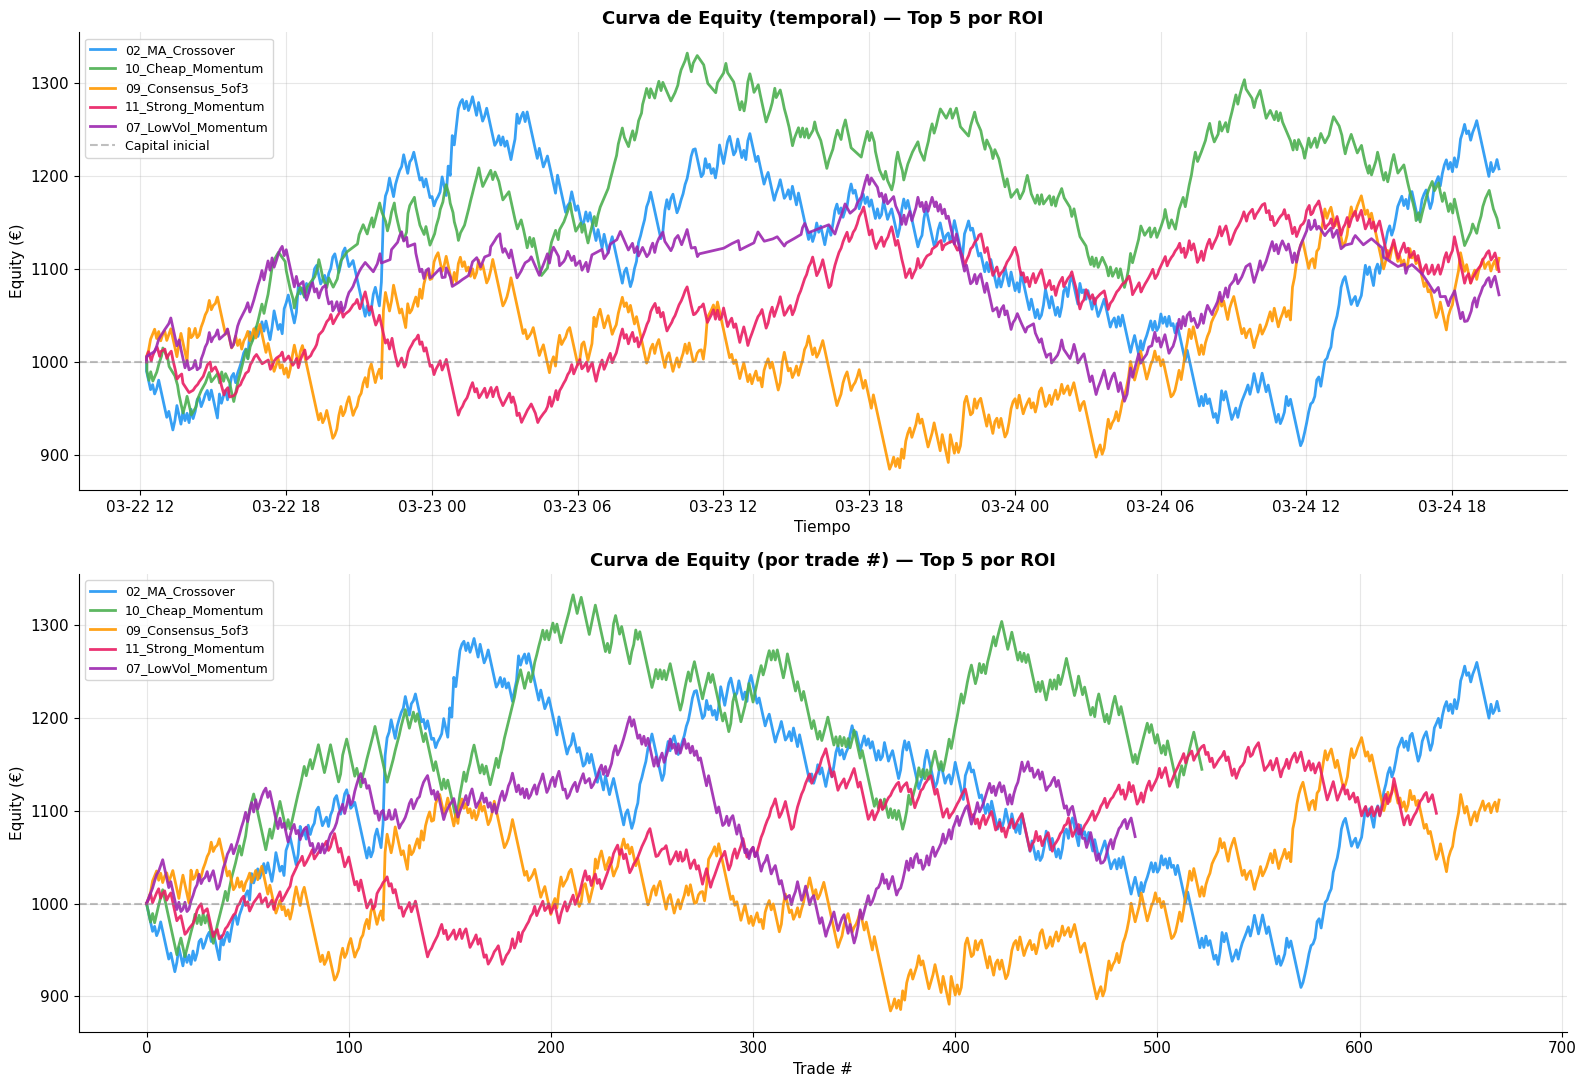

In [35]:
# =============================================================================
# 11. CURVAS DE EQUITY — TOP 5
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 11))

# ── Panel 1: Equity por timestamp (temporal) ─────────────────────────────────
ax = axes[0]
for i, name in enumerate(top5_names):
    eq = equity_curves[name]
    if len(eq) > 1:
        ax.plot(eq.index, eq.values, label=name, color=TOP5_COLORS[i], lw=2, alpha=0.9)

ax.axhline(CFG['INIT_CAPITAL'], ls='--', color='gray', alpha=0.5, label='Capital inicial')
ax.set_title('Curva de Equity (temporal) — Top 5 por ROI', fontweight='bold', fontsize=13)
ax.set_ylabel('Equity (€)')
ax.set_xlabel('Tiempo')
ax.legend(fontsize=9, loc='upper left')

# ── Panel 2: Equity por número de trade ──────────────────────────────────────
ax = axes[1]
for i, name in enumerate(top5_names):
    eq = equity_curves[name]
    if len(eq) > 1:
        ax.plot(range(len(eq)), eq.values, label=name, color=TOP5_COLORS[i], lw=2, alpha=0.9)

ax.axhline(CFG['INIT_CAPITAL'], ls='--', color='gray', alpha=0.5)
ax.set_title('Curva de Equity (por trade #) — Top 5 por ROI', fontweight='bold', fontsize=13)
ax.set_ylabel('Equity (€)')
ax.set_xlabel('Trade #')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

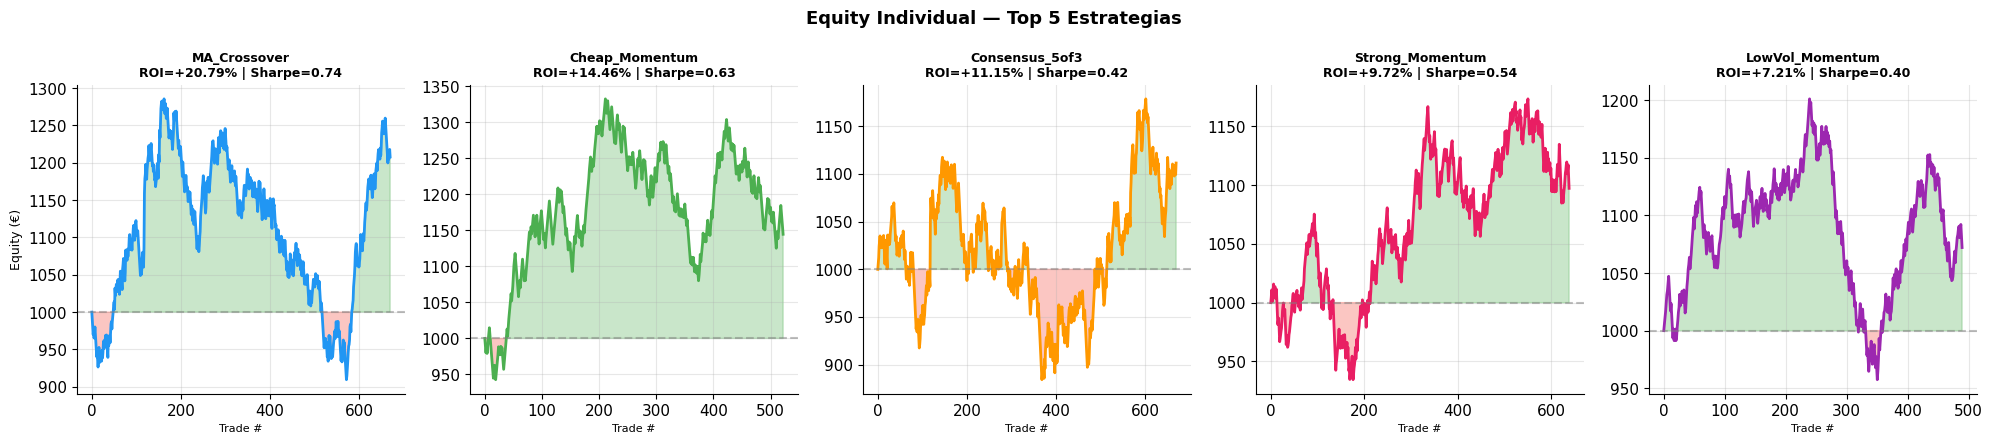

In [36]:
# =============================================================================
# 11b. EQUITY INDIVIDUAL POR ESTRATEGIA (Top 5)
# =============================================================================
fig, axes = plt.subplots(1, TOP_N, figsize=(20, 4.5))

for i, name in enumerate(top5_names):
    ax = axes[i]
    tdf = trade_logs[name]
    eq  = equity_curves[name]
    s   = results[name]

    if len(eq) > 1:
        ax.fill_between(range(len(eq)), CFG['INIT_CAPITAL'], eq.values,
                        where=eq.values >= CFG['INIT_CAPITAL'],
                        color='#4CAF50', alpha=0.3)
        ax.fill_between(range(len(eq)), CFG['INIT_CAPITAL'], eq.values,
                        where=eq.values < CFG['INIT_CAPITAL'],
                        color='#F44336', alpha=0.3)
        ax.plot(range(len(eq)), eq.values, color=TOP5_COLORS[i], lw=2)
    ax.axhline(CFG['INIT_CAPITAL'], ls='--', color='gray', alpha=0.5)

    short = name[3:]  # quitar "01_"
    ax.set_title(f"{short}\nROI={s['roi']:+.2%} | Sharpe={s['sharpe']:.2f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Trade #', fontsize=8)
    if i == 0:
        ax.set_ylabel('Equity (€)', fontsize=9)

plt.suptitle('Equity Individual — Top 5 Estrategias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12 · Análisis de Timing de Mercado — Top 5

¿En qué momento del mercado (market_progress) se ejecutan los trades?
¿Hay diferencia de rendimiento según cuándo se entra?

ANÁLISIS DE TIMING — ¿Cuándo se ejecutan los trades?
══════════════════════════════════════════════════════════════════════════════════════════


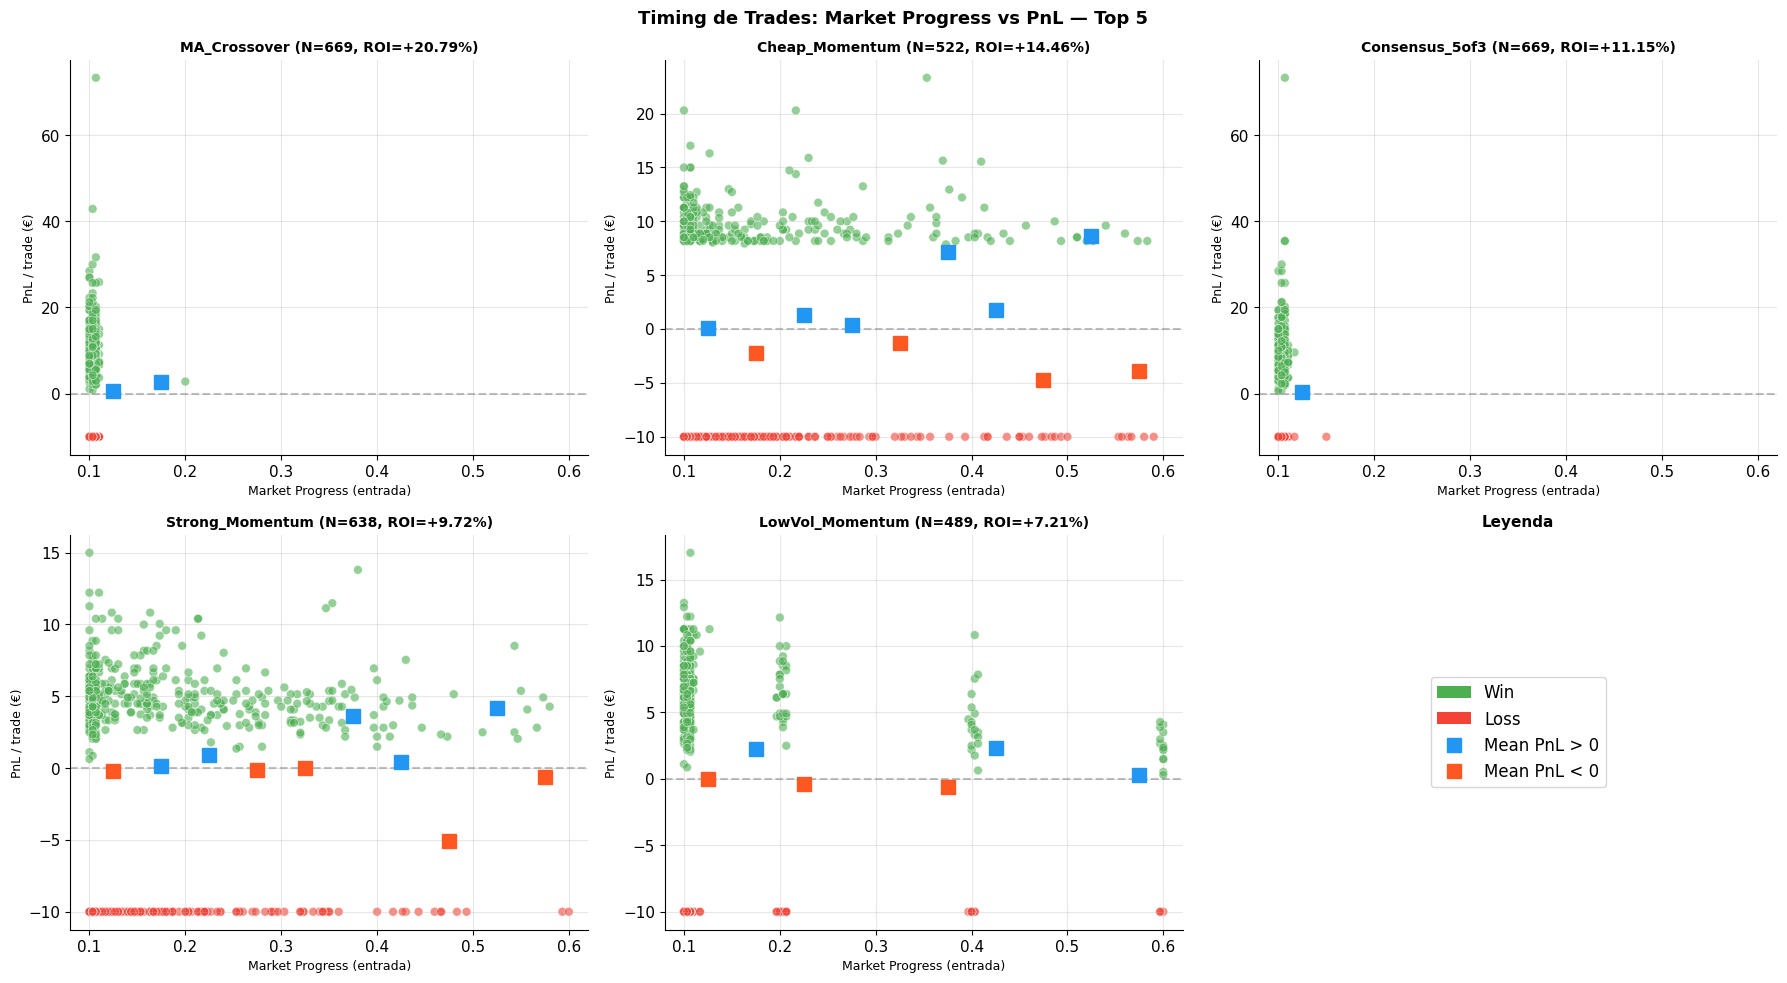

In [37]:
# =============================================================================
# 12. TIMING DE TRADES — TOP 5
# =============================================================================
print("ANÁLISIS DE TIMING — ¿Cuándo se ejecutan los trades?")
print("═" * 90)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, name in enumerate(top5_names):
    tdf = trade_logs[name]
    s = results[name]
    ax = axes_flat[i]

    if tdf.empty:
        ax.text(0.5, 0.5, 'Sin trades', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name, fontsize=10)
        continue

    prog = tdf['entry_progress'].values
    pnl = tdf['pnl'].values
    won = tdf['won'].values

    # Scatter: progress vs pnl, coloreado por win/loss
    colors_sc = ['#4CAF50' if w else '#F44336' for w in won]
    ax.scatter(prog, pnl, c=colors_sc, alpha=0.6, s=40, edgecolors='white', lw=0.5)
    ax.axhline(0, ls='--', color='gray', alpha=0.5)

    # Media de PnL por franja de progress
    bins = np.arange(CFG['ENTRY_LO'], CFG['ENTRY_HI'] + 0.05, 0.05)
    tdf_c = tdf.copy()
    tdf_c['prog_bin'] = pd.cut(tdf_c['entry_progress'], bins=bins)
    bin_stats = tdf_c.groupby('prog_bin', observed=True).agg(
        mean_pnl=('pnl', 'mean'), count=('pnl', 'count'),
        wr=('won', 'mean')
    )
    for b, row_b in bin_stats.iterrows():
        mid = (b.left + b.right) / 2
        c = '#2196F3' if row_b['mean_pnl'] > 0 else '#FF5722'
        ax.plot(mid, row_b['mean_pnl'], 's', color=c, markersize=10, zorder=5)

    short = name[3:]
    ax.set_title(f"{short} (N={s['n']}, ROI={s['roi']:+.2%})",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Market Progress (entrada)', fontsize=9)
    ax.set_ylabel('PnL / trade (€)', fontsize=9)
    ax.set_xlim(CFG['ENTRY_LO'] - 0.02, CFG['ENTRY_HI'] + 0.02)

# Último panel: leyenda
ax_leg = axes_flat[5]
ax_leg.axis('off')
ax_leg.legend(
    handles=[
        Patch(facecolor='#4CAF50', label='Win'),
        Patch(facecolor='#F44336', label='Loss'),
        plt.Line2D([0],[0], marker='s', color='#2196F3', ls='', markersize=10, label='Mean PnL > 0'),
        plt.Line2D([0],[0], marker='s', color='#FF5722', ls='', markersize=10, label='Mean PnL < 0'),
    ],
    loc='center', fontsize=12, frameon=True
)
ax_leg.set_title('Leyenda', fontsize=11, fontweight='bold')

plt.suptitle('Timing de Trades: Market Progress vs PnL — Top 5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

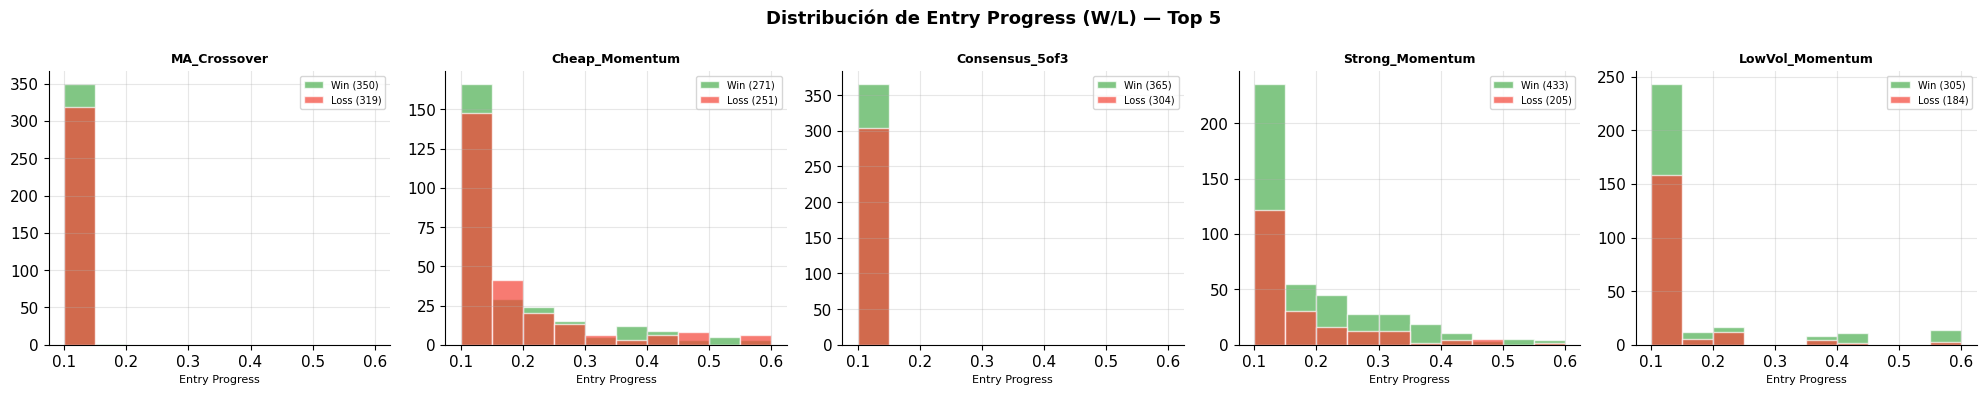

In [38]:
# =============================================================================
# 12b. DISTRIBUCIÓN DE ENTRY PROGRESS — TOP 5
# =============================================================================
fig, axes = plt.subplots(1, TOP_N, figsize=(20, 4))

for i, name in enumerate(top5_names):
    ax = axes[i]
    tdf = trade_logs[name]
    if tdf.empty:
        ax.text(0.5, 0.5, 'Sin trades', ha='center', va='center', transform=ax.transAxes)
        continue

    wins  = tdf[tdf['won']]['entry_progress']
    loses = tdf[~tdf['won']]['entry_progress']

    bins = np.arange(CFG['ENTRY_LO'], CFG['ENTRY_HI'] + 0.05, 0.05)
    ax.hist(wins, bins=bins, alpha=0.7, color='#4CAF50', label=f'Win ({len(wins)})', edgecolor='white')
    ax.hist(loses, bins=bins, alpha=0.7, color='#F44336', label=f'Loss ({len(loses)})', edgecolor='white')

    short = name[3:]
    ax.set_title(short, fontsize=9, fontweight='bold')
    ax.set_xlabel('Entry Progress', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Distribución de Entry Progress (W/L) — Top 5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# =============================================================================
# 12c. TABLA TIMING DETALLADA — TOP 5
# =============================================================================
print("TIMING DETALLADO — PnL y WR por franja de Market Progress")
print("═" * 100)

progress_bins = [(0.10, 0.20), (0.20, 0.30), (0.30, 0.40), (0.40, 0.50), (0.50, 0.60)]

for name in top5_names:
    tdf = trade_logs[name]
    if tdf.empty:
        continue

    print(f"\n  ── {name} ──")
    print(f"  {'Franja':<16} {'N':>5} {'WR':>7} {'PnL':>10} {'Avg PnL':>10} {'Avg Ask':>8}")
    print(f"  {'─' * 60}")

    for lo, hi in progress_bins:
        mask = (tdf['entry_progress'] >= lo) & (tdf['entry_progress'] < hi)
        sub = tdf[mask]
        if len(sub) == 0:
            continue
        wr = sub['won'].mean()
        pnl = sub['pnl'].sum()
        avg_pnl = sub['pnl'].mean()
        avg_ask = sub['entry_ask'].mean()
        print(f"  [{lo:.2f}, {hi:.2f})    {len(sub):>5} {wr:>6.1%} "
              f"{pnl:>+10.2f} {avg_pnl:>+10.4f} {avg_ask:>8.3f}")

    # Resumen
    print(f"  {'TOTAL':<16} {len(tdf):>5} {tdf['won'].mean():>6.1%} "
          f"{tdf['pnl'].sum():>+10.2f} {tdf['pnl'].mean():>+10.4f} "
          f"{tdf['entry_ask'].mean():>8.3f}")

TIMING DETALLADO — PnL y WR por franja de Market Progress
════════════════════════════════════════════════════════════════════════════════════════════════════

  ── 02_MA_Crossover ──
  Franja               N      WR        PnL    Avg PnL  Avg Ask
  ────────────────────────────────────────────────────────────
  [0.10, 0.20)      668  52.2%    +205.10    +0.3070    0.508
  [0.20, 0.30)        1 100.0%      +2.81    +2.8105    0.780
  TOTAL              669  52.3%    +207.91    +0.3108    0.509

  ── 10_Cheap_Momentum ──
  Franja               N      WR        PnL    Avg PnL  Avg Ask
  ────────────────────────────────────────────────────────────
  [0.10, 0.20)      382  50.5%     -14.62    -0.0383    0.507
  [0.20, 0.30)       73  56.2%     +93.82    +1.2851    0.500
  [0.30, 0.40)       27  63.0%     +82.93    +3.0714    0.494
  [0.40, 0.50)       25  48.0%     -15.63    -0.6252    0.511
  [0.50, 0.60)       15  53.3%      -1.87    -0.1248    0.511
  TOTAL              522  51.9%    +14

---
## 13 · Distribución de PnL — 20 Estrategias

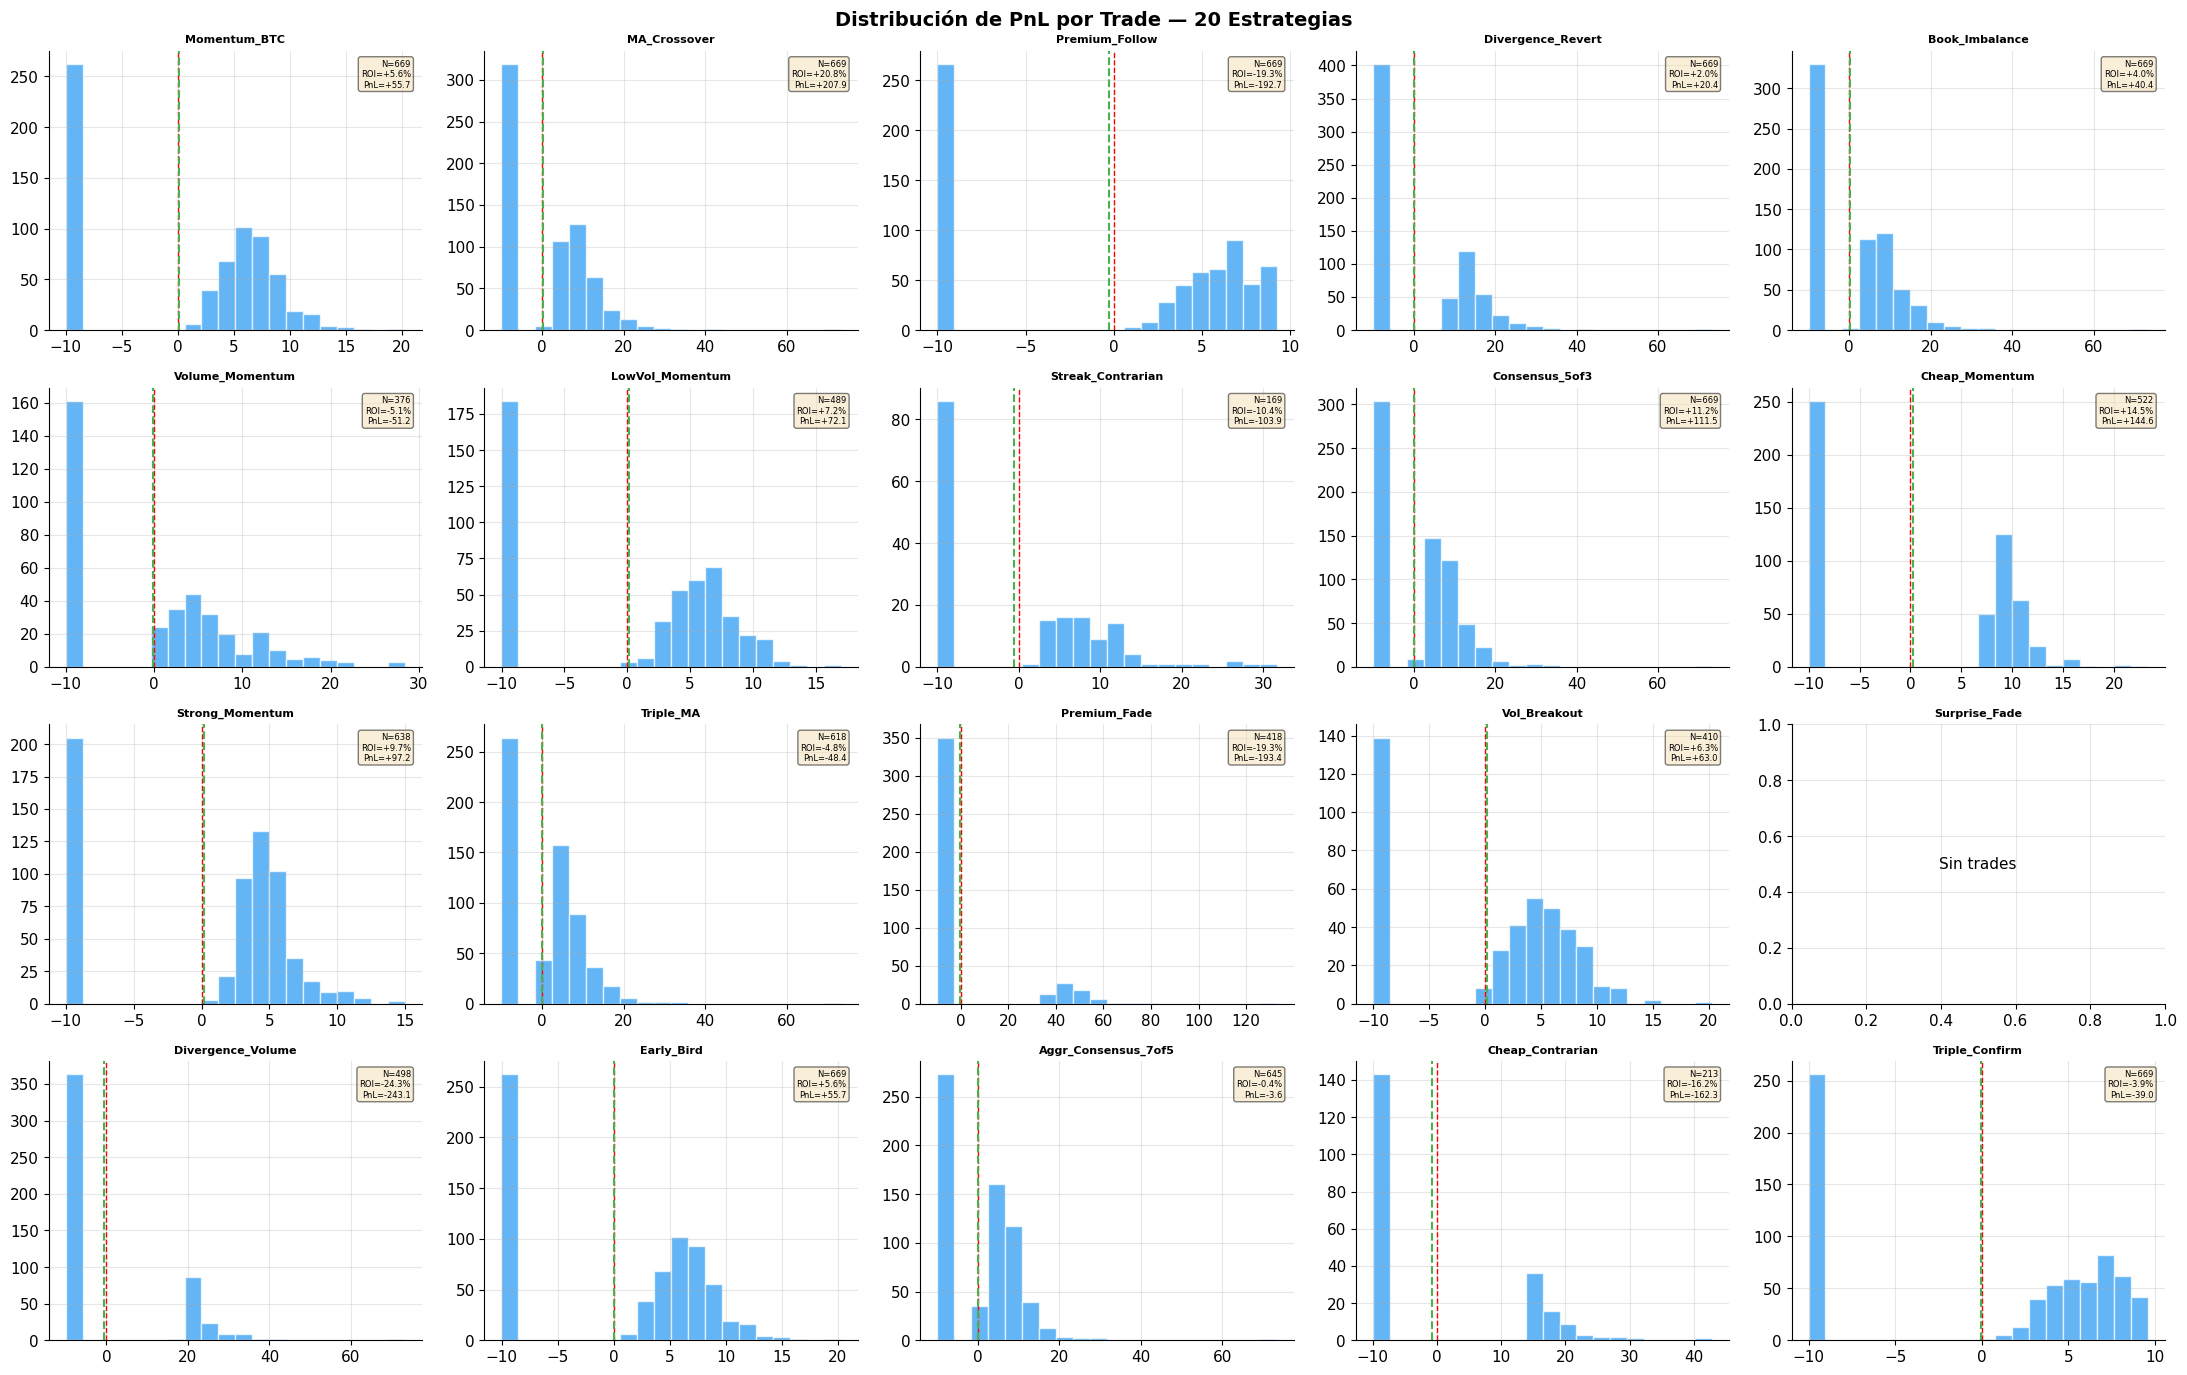

In [40]:
# =============================================================================
# 13. DISTRIBUCIÓN DE PnL — 20 ESTRATEGIAS
# =============================================================================
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
axes_f = axes.flatten()

for i, (name, _) in enumerate(STRATEGIES):
    ax = axes_f[i]
    tdf = trade_logs[name]
    s = results[name]

    if tdf.empty:
        ax.text(0.5, 0.5, 'Sin trades', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name[3:], fontsize=8, fontweight='bold')
        continue

    pnl_vals = tdf['pnl'].values
    ax.hist(pnl_vals, bins=20, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(pnl_vals.mean(), ls='--', color='#4CAF50', lw=1.5)
    ax.set_title(name[3:], fontsize=8, fontweight='bold')

    ax.text(0.97, 0.97,
            f"N={s['n']}\nROI={s['roi']:+.1%}\nPnL={s['pnl']:+.1f}",
            transform=ax.transAxes, fontsize=6, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribución de PnL por Trade — 20 Estrategias', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14 · Heatmap Comparativo

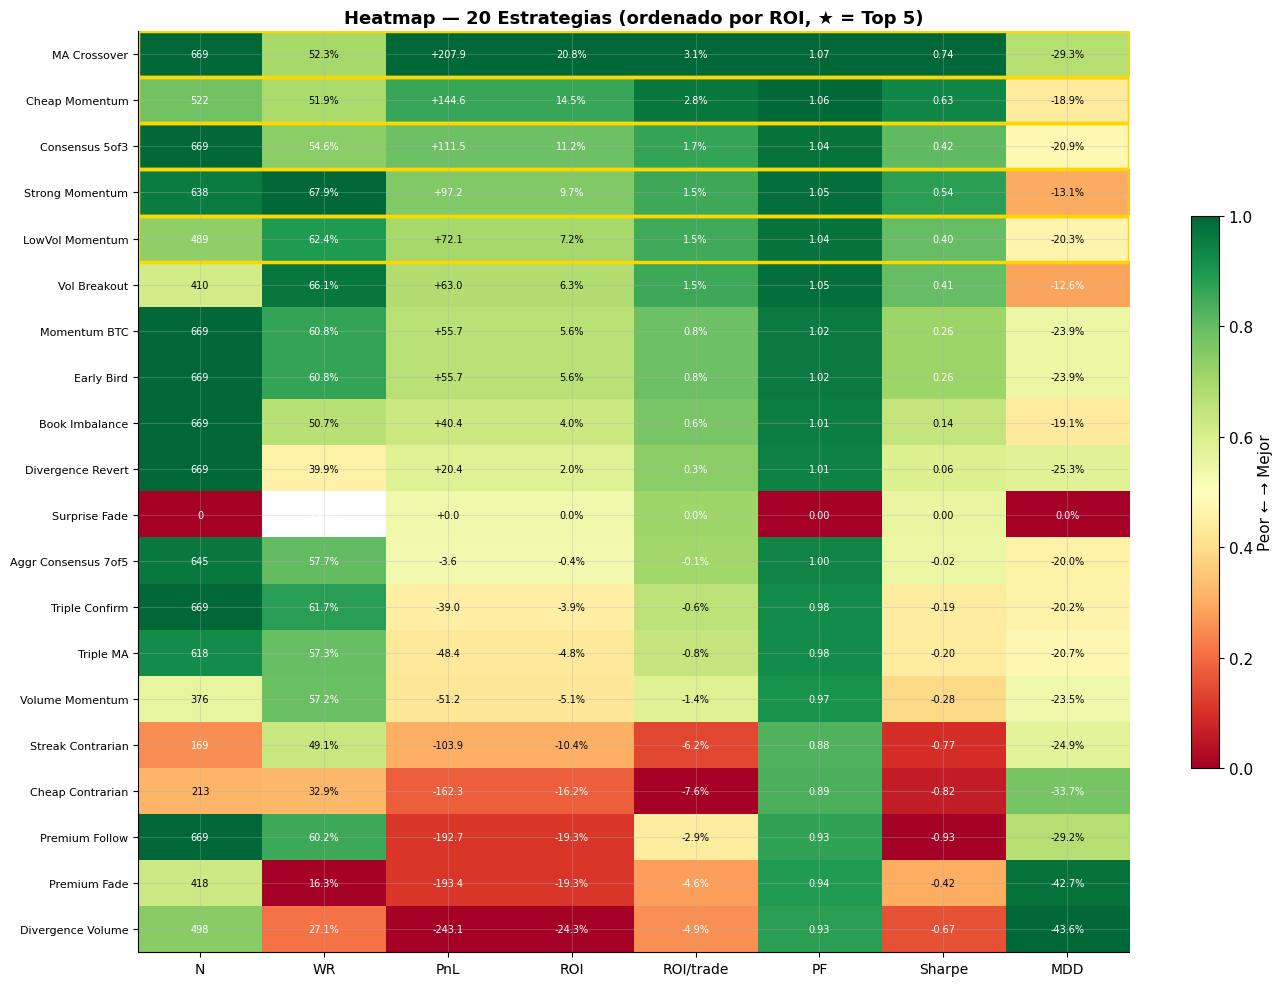

In [41]:
# =============================================================================
# 14. HEATMAP — 20 ESTRATEGIAS
# =============================================================================
metrics_display = ranking[['n', 'wr', 'pnl', 'roi', 'roi_per_trade', 'pf', 'sharpe', 'mdd']].copy()
metrics_display.columns = ['N', 'WR', 'PnL', 'ROI', 'ROI/trade', 'PF', 'Sharpe', 'MDD']

fig, ax = plt.subplots(figsize=(14, 10))

norm_df = metrics_display.copy()
for col in norm_df.columns:
    rng = norm_df[col].max() - norm_df[col].min()
    if rng > 0:
        norm_df[col] = (norm_df[col] - norm_df[col].min()) / rng
    else:
        norm_df[col] = 0.5
norm_df['MDD'] = 1 - norm_df['MDD']  # invertir (menos negativo = mejor)

im = ax.imshow(norm_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(metrics_display.columns)))
ax.set_xticklabels(metrics_display.columns, fontsize=10)
ax.set_yticks(range(len(metrics_display)))
labels_y = [n[3:].replace('_', ' ') for n in metrics_display.index]
ax.set_yticklabels(labels_y, fontsize=8)

for i in range(len(metrics_display)):
    for j in range(len(metrics_display.columns)):
        val = metrics_display.iloc[i, j]
        col_name = metrics_display.columns[j]
        if col_name in ['WR', 'ROI', 'ROI/trade', 'MDD']:
            txt = f"{val:.1%}"
        elif col_name in ['PnL']:
            txt = f"{val:+.1f}"
        elif col_name in ['Sharpe', 'PF']:
            txt = f"{val:.2f}"
        else:
            txt = f"{val:.0f}"
        nv = norm_df.iloc[i, j]
        ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                color='black' if 0.3 < nv < 0.7 else 'white')

# Marcar top 5 con borde
for idx, name in enumerate(ranking.index):
    if name in top5_names:
        ax.add_patch(plt.Rectangle((-0.5, idx-0.5), len(metrics_display.columns), 1,
                                    fill=False, edgecolor='gold', lw=2.5))

ax.set_title('Heatmap — 20 Estrategias (ordenado por ROI, ★ = Top 5)',
             fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, label='Peor ← → Mejor', shrink=0.6)
plt.tight_layout()
plt.show()

---
## 15 · Validación Monte Carlo — Top 5

In [42]:
# =============================================================================
# 15. MONTE CARLO — TOP 5 ESTRATEGIAS
# =============================================================================
N_MC_ITERS = 30
TEST_PCT   = 0.45
rng = np.random.RandomState(SEED)

all_markets = fe['market_slug'].unique().tolist()
N_mkts = len(all_markets)
n_test = int(N_mkts * TEST_PCT)

print(f"Monte Carlo: {N_MC_ITERS} iteraciones")
print(f"Mercados: {N_mkts} total → {n_test} test por iteración")
print(f"Estrategias: {top5_names}")

mc_all = {name: [] for name in top5_names}

for it in range(N_MC_ITERS):
    shuffled = rng.permutation(all_markets)
    mc_test_m = shuffled[:n_test].tolist()
    mc_test_df = fe[fe['market_slug'].isin(mc_test_m)].copy()

    for name in top5_names:
        signal_fn = top5_fns[name]
        tdf, eq_s = run_backtest_rule(mc_test_df, CFG, signal_fn)
        stats = compute_stats(tdf, eq_s, CFG)
        mc_all[name].append(stats)

# ── Resumen ──────────────────────────────────────────────────────────────────
print(f"\n{'═' * 85}")
print(f"  MONTE CARLO — RESUMEN ({N_MC_ITERS} iteraciones, {n_test} mercados/iter)")
print(f"{'═' * 85}")

mc_summary = {}
for name in top5_names:
    mc_df = pd.DataFrame(mc_all[name])
    mc_valid = mc_df[mc_df['n'] > 0]
    mc_summary[name] = mc_valid

    print(f"\n  ── {name} ──")
    if len(mc_valid) == 0:
        print("    Sin trades en ninguna iteración.")
        continue

    for col, label, fmt in [
        ('n',             'N trades',       '.1f'),
        ('wr',            'Win Rate',       '.1%'),
        ('pnl',           'PnL (€)',        '+.2f'),
        ('roi',           'ROI',            '+.2%'),
        ('roi_per_trade', 'ROI/trade',      '+.2%'),
        ('pf',            'Profit Factor',  '.2f'),
        ('mdd',           'Max Drawdown',   '.2%'),
        ('sharpe',        'Sharpe',         '.2f'),
    ]:
        v = mc_valid[col].dropna()
        print(f"    {label:<16} media={v.mean():{fmt}}  med={v.median():{fmt}}  "
              f"std={v.std():{fmt}}")

    pct_profit = (mc_valid['roi'] > 0).mean()
    print(f"    Iteraciones con ROI>0: {pct_profit:.0%} "
          f"({(mc_valid['roi']>0).sum()}/{len(mc_valid)})")

Monte Carlo: 30 iteraciones
Mercados: 1485 total → 668 test por iteración
Estrategias: ['02_MA_Crossover', '10_Cheap_Momentum', '09_Consensus_5of3', '11_Strong_Momentum', '07_LowVol_Momentum']

═════════════════════════════════════════════════════════════════════════════════════
  MONTE CARLO — RESUMEN (30 iteraciones, 668 mercados/iter)
═════════════════════════════════════════════════════════════════════════════════════

  ── 02_MA_Crossover ──
    N trades         media=668.0  med=668.0  std=0.0
    Win Rate         media=48.8%  med=48.9%  std=1.5%
    PnL (€)          media=-256.09  med=-264.26  std=+223.20
    ROI              media=-25.61%  med=-26.43%  std=+22.32%
    ROI/trade        media=-3.83%  med=-3.96%  std=+3.34%
    Profit Factor    media=0.93  med=0.92  std=0.06
    Max Drawdown     media=-49.83%  med=-51.70%  std=15.19%
    Sharpe           media=-0.93  med=-0.95  std=0.82
    Iteraciones con ROI>0: 13% (4/30)

  ── 10_Cheap_Momentum ──
    N trades         media=515.

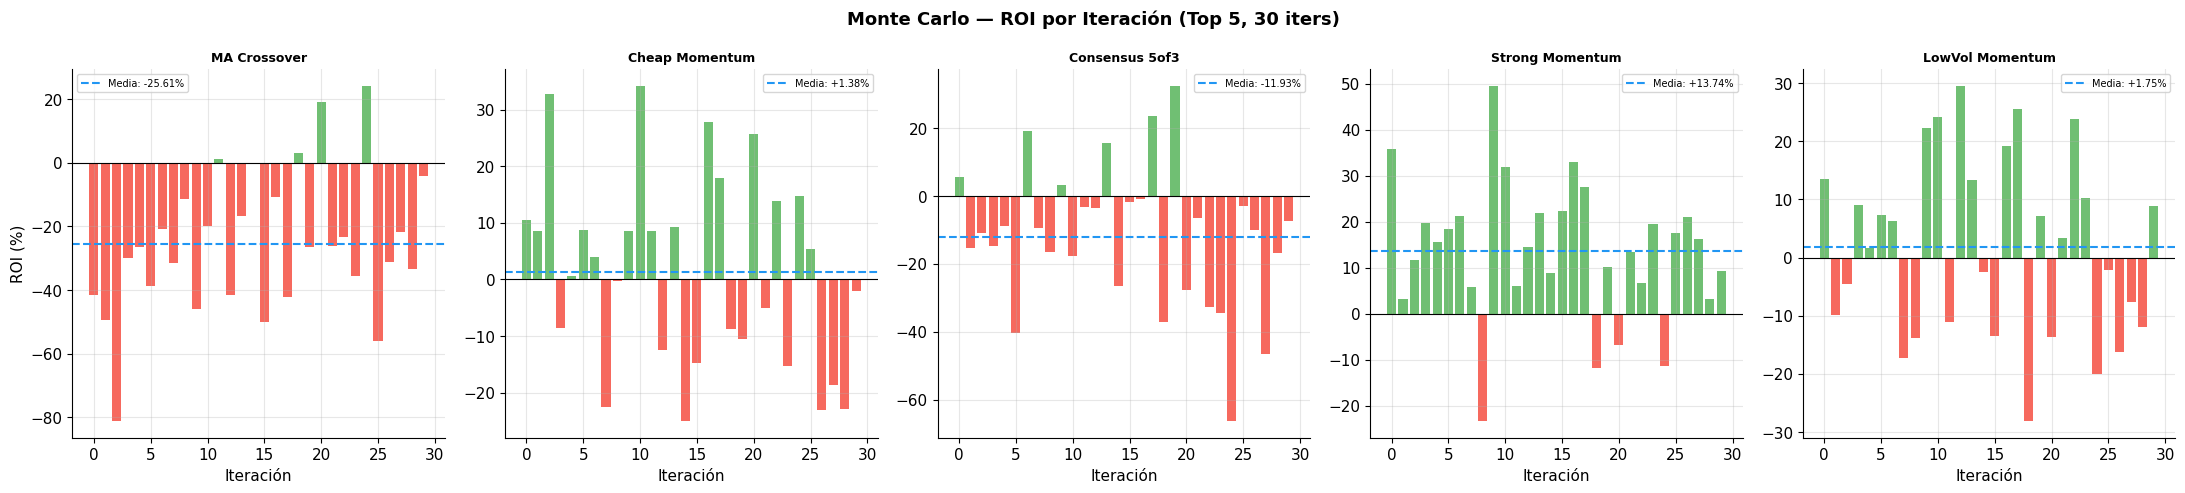

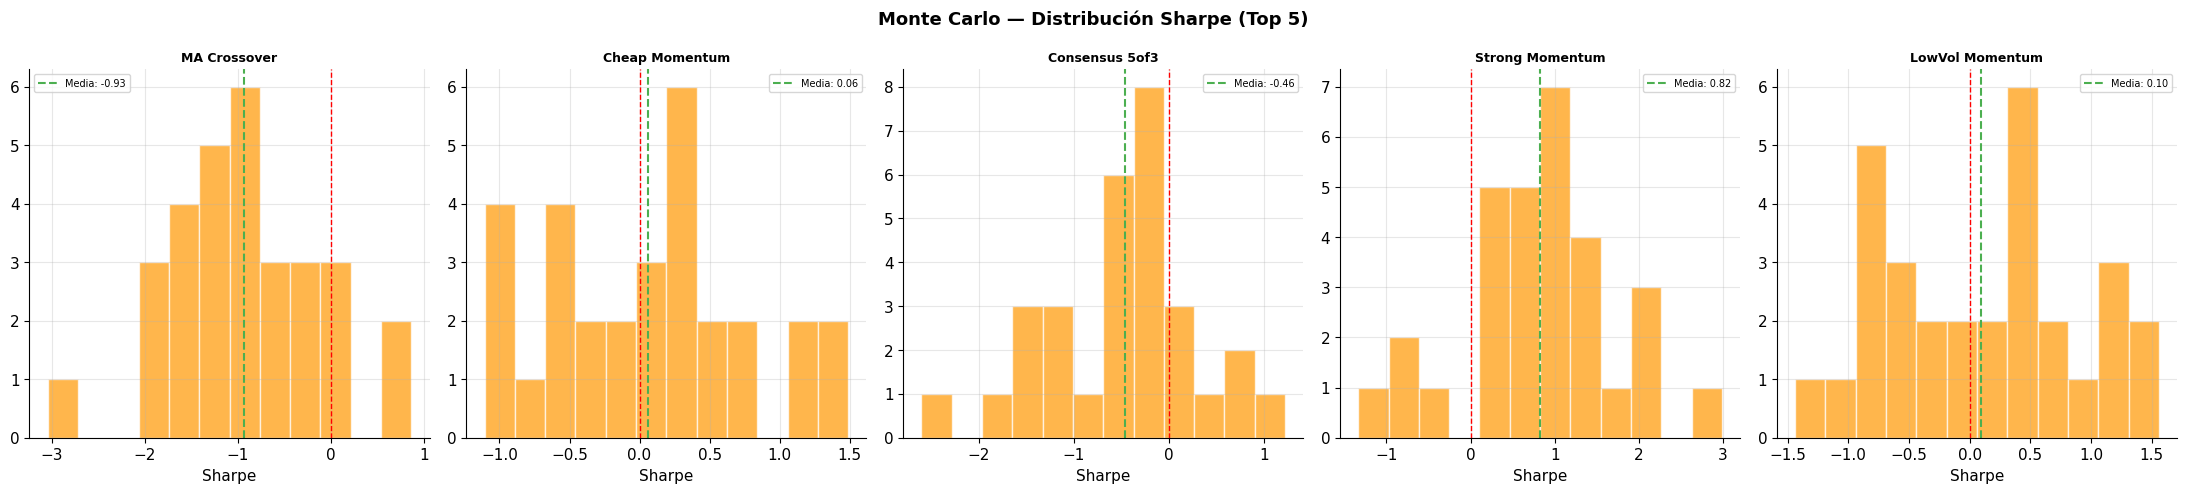

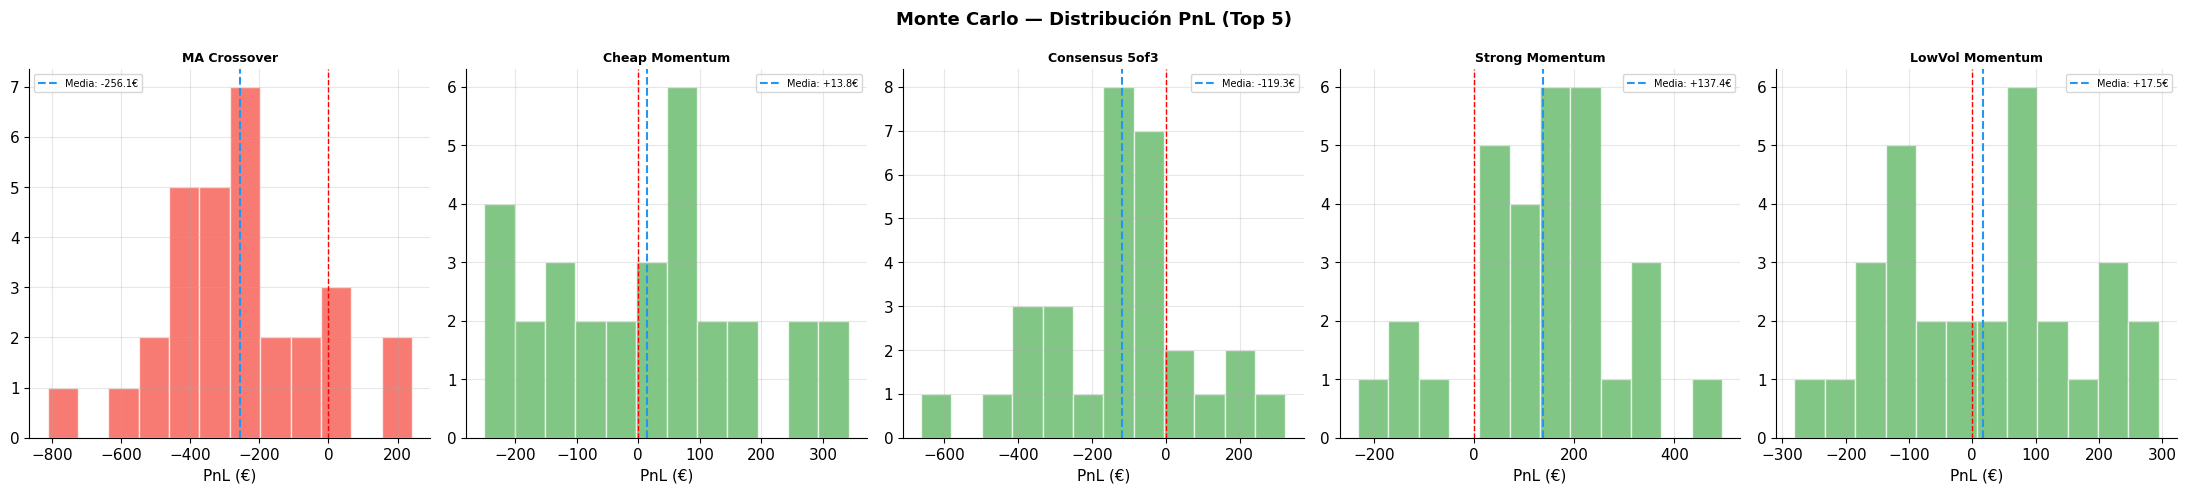

In [43]:
# =============================================================================
# 15b. GRÁFICOS MONTE CARLO — ROI
# =============================================================================
fig, axes = plt.subplots(1, TOP_N, figsize=(22, 5))

for i, name in enumerate(top5_names):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty or len(mc_v) < 2:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name[3:], fontsize=9)
        continue

    c_roi = ['#4CAF50' if v > 0 else '#F44336' for v in mc_v['roi']]
    ax.bar(range(len(mc_v)), mc_v['roi'].values * 100, color=c_roi, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(mc_v['roi'].mean() * 100, ls='--', color='#2196F3', lw=1.5,
               label=f"Media: {mc_v['roi'].mean():+.2%}")
    ax.set_title(name[3:].replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_ylabel('ROI (%)' if i == 0 else '')
    ax.set_xlabel('Iteración')
    ax.legend(fontsize=7)

plt.suptitle(f'Monte Carlo — ROI por Iteración (Top 5, {N_MC_ITERS} iters)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Distribución de Sharpe ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, TOP_N, figsize=(22, 5))

for i, name in enumerate(top5_names):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty or len(mc_v) < 2:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name[3:], fontsize=9)
        continue

    ax.hist(mc_v['sharpe'], bins=12, color='#FF9800', alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(mc_v['sharpe'].mean(), ls='--', color='#4CAF50', lw=1.5,
               label=f"Media: {mc_v['sharpe'].mean():.2f}")
    ax.set_title(name[3:].replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Sharpe')
    ax.legend(fontsize=7)

plt.suptitle(f'Monte Carlo — Distribución Sharpe (Top 5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Distribución de PnL ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, TOP_N, figsize=(22, 5))

for i, name in enumerate(top5_names):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty or len(mc_v) < 2:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name[3:], fontsize=9)
        continue

    c_pnl = ['#4CAF50' if v > 0 else '#F44336' for v in mc_v['pnl']]
    ax.hist(mc_v['pnl'], bins=12, color=c_pnl[0], alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(mc_v['pnl'].mean(), ls='--', color='#2196F3', lw=1.5,
               label=f"Media: {mc_v['pnl'].mean():+.1f}€")
    ax.set_title(name[3:].replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('PnL (€)')
    ax.legend(fontsize=7)

plt.suptitle(f'Monte Carlo — Distribución PnL (Top 5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 16 · Análisis por Dirección — Top 5

In [44]:
# =============================================================================
# 16. ANÁLISIS POR DIRECCIÓN (UP vs DOWN) — TOP 5
# =============================================================================
print("ANÁLISIS POR DIRECCIÓN — Top 5")
print("═" * 90)
print(f"{'Estrategia':<26} {'N_UP':>5} {'WR_UP':>7} {'PnL_UP':>10} "
      f"{'N_DN':>5} {'WR_DN':>7} {'PnL_DN':>10} {'Mejor':>8}")
print("─" * 90)

for name in top5_names:
    tdf = trade_logs[name]
    if tdf.empty:
        continue

    up_t = tdf[tdf['direction'] == 'UP']
    dn_t = tdf[tdf['direction'] == 'DOWN']

    n_up = len(up_t)
    n_dn = len(dn_t)
    wr_up = up_t['won'].mean() if n_up > 0 else np.nan
    wr_dn = dn_t['won'].mean() if n_dn > 0 else np.nan
    pnl_up = up_t['pnl'].sum() if n_up > 0 else 0
    pnl_dn = dn_t['pnl'].sum() if n_dn > 0 else 0

    wr_up_s = f"{wr_up:.1%}" if not np.isnan(wr_up) else 'n/a'
    wr_dn_s = f"{wr_dn:.1%}" if not np.isnan(wr_dn) else 'n/a'
    mejor = 'UP' if pnl_up > pnl_dn else 'DOWN'

    print(f"{name:<26} {n_up:>5} {wr_up_s:>7} {pnl_up:>+10.2f} "
          f"{n_dn:>5} {wr_dn_s:>7} {pnl_dn:>+10.2f} {mejor:>8}")

ANÁLISIS POR DIRECCIÓN — Top 5
══════════════════════════════════════════════════════════════════════════════════════════
Estrategia                  N_UP   WR_UP     PnL_UP  N_DN   WR_DN     PnL_DN    Mejor
──────────────────────────────────────────────────────────────────────────────────────────
02_MA_Crossover              333   53.8%    +267.80   336   50.9%     -59.89       UP
10_Cheap_Momentum            251   52.2%    +101.24   271   51.7%     +43.39       UP
09_Consensus_5of3            328   56.1%    +185.22   341   53.1%     -73.72       UP
11_Strong_Momentum           319   69.0%    +142.06   319   66.8%     -44.81       UP
07_LowVol_Momentum           241   64.7%    +103.26   248   60.1%     -31.14       UP


---
## 17 · Detalle de Trades — Mejor Estrategia

In [45]:
# =============================================================================
# 17. DETALLE — MEJOR ESTRATEGIA POR ROI
# =============================================================================
best_name = ranking.index[0]
best_log  = trade_logs[best_name]
best_s    = results[best_name]

print(f"{'═' * 65}")
print(f"  DETALLE — {best_name}")
print(f"{'═' * 65}")
print(f"  N trades       : {best_s['n']}")
print(f"  Win Rate       : {best_s['wr']:.1%}")
print(f"  PnL Total      : {best_s['pnl']:+.2f} €")
print(f"  ROI            : {best_s['roi']:+.2%}")
print(f"  ROI/trade      : {best_s['roi_per_trade']:+.2%}")
print(f"  Profit Factor  : {best_s['pf']:.3f}")
print(f"  Sharpe         : {best_s['sharpe']:.3f}")
print(f"  Max Drawdown   : {best_s['mdd']:.2%}")
print(f"  Avg PnL/trade  : {best_s['avg_pnl']:+.4f} €")
print(f"  Max win        : {best_s['max_win']:+.4f}")
print(f"  Max loss       : {best_s['max_loss']:+.4f}")
print(f"  Total staked   : {best_s['total_staked']:.0f} €")

if not best_log.empty:
    dups = best_log.groupby('market').size()
    multi = (dups > 1).sum()
    print(f"\n  ✓ Trades duplicados por mercado: {multi}")
    print(f"  ✓ Restricción entry_progress ≤ {CFG['ENTRY_HI']} "
          f"(max real: {best_log['entry_progress'].max():.3f})")

    print(f"\n  Primeros 25 trades:")
    cols = ['market', 'direction', 'resolution', 'entry_progress',
            'entry_ask', 'won', 'pnl']
    display_cols = [c for c in cols if c in best_log.columns]
    pd.set_option('display.max_colwidth', 40)
    print(best_log[display_cols].head(25).to_string(index=False))

═════════════════════════════════════════════════════════════════
  DETALLE — 02_MA_Crossover
═════════════════════════════════════════════════════════════════
  N trades       : 669
  Win Rate       : 52.3%
  PnL Total      : +207.91 €
  ROI            : +20.79%
  ROI/trade      : +3.11%
  Profit Factor  : 1.065
  Sharpe         : 0.738
  Max Drawdown   : -29.25%
  Avg PnL/trade  : +0.3108 €
  Max win        : +73.3233
  Max loss       : -10.0100
  Total staked   : 6690 €

  ✓ Trades duplicados por mercado: 0
  ✓ Restricción entry_progress ≤ 0.6 (max real: 0.200)

  Primeros 25 trades:
                  market direction resolution  entry_progress  entry_ask   won        pnl
btc-updown-5m-1774181700      DOWN         up          0.1000       0.38 False -10.010000
btc-updown-5m-1774182000      DOWN         up          0.1000       0.40 False -10.010000
btc-updown-5m-1774182300      DOWN         up          0.1000       0.56 False -10.010000
btc-updown-5m-1774182600      DOWN       down 

---
## 18 · Resumen Final y Recomendación

In [46]:
# =============================================================================
# 18. RESUMEN FINAL
# =============================================================================
D = '═' * 75
print(D)
print('  RESUMEN FINAL — 20 Estrategias Rule-Based · Polymarket BTC')
print(D)

print(f"\n  Configuración:")
print(f"    Dataset: {fe['market_slug'].nunique()} mercados")
print(f"    Test set: {test_fe['market_slug'].nunique()} mercados")
print(f"    Ventana: progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}] "
      f"(≥{1-CFG['ENTRY_HI']:.0%} restante al cierre)")
print(f"    Stake: {CFG['STAKE']}€ | Capital: {CFG['INIT_CAPITAL']}€")
print(f"    Restricción: 1 trade/mercado, hold hasta resolución")

print(f"\n  RANKING COMPLETO (por ROI):")
print(f"  {'Rk':>3} {'Estrategia':<26} {'ROI':>8} {'PnL(€)':>10} {'WR':>7} "
      f"{'Sharpe':>8} {'Status':>12}")
print(f"  {'─' * 78}")

for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    in_top5 = '→ TOP5' if name in top5_names else ''
    roi_ok  = row['roi'] > 0
    sh_ok   = row['sharpe'] > 0
    status  = '✅ OK' if roi_ok and sh_ok else '❌'
    wr_s    = f"{row['wr']:.1%}" if not np.isnan(row['wr']) else 'n/a'
    print(f"  {rank:>3} {name:<26} {row['roi']:>+7.2%} {row['pnl']:>+10.2f} "
          f"{wr_s:>7} {row['sharpe']:>8.3f} {status:>6} {in_top5}")

# Monte Carlo para top 5
print(f"\n  MONTE CARLO (Top 5, {N_MC_ITERS} iters):")
print(f"  {'Estrategia':<26} {'ROI_med':>10} {'Sharpe_med':>12} {'%ROI>0':>8}")
print(f"  {'─' * 60}")

for name in top5_names:
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty:
        print(f"  {name:<26} {'sin datos':>10}")
        continue
    print(f"  {name:<26} {mc_v['roi'].mean():>+9.2%} "
          f"{mc_v['sharpe'].mean():>12.2f} "
          f"{(mc_v['roi']>0).mean():>7.0%}")

print(f"\n  RECOMENDACIÓN:")
candidates = ranking[(ranking['roi'] > 0) & (ranking['sharpe'] > 0)]
if len(candidates) > 0:
    print(f"  {len(candidates)} estrategia(s) con ROI>0 y Sharpe>0:")
    for name, row in candidates.head(5).iterrows():
        mc_info = ''
        if name in mc_summary and len(mc_summary[name]) > 0:
            mc_v = mc_summary[name]
            mc_info = (f" | MC: ROI={mc_v['roi'].mean():+.2%}, "
                       f"Sharpe={mc_v['sharpe'].mean():.2f}, "
                       f"%rent={((mc_v['roi']>0).mean()):.0%}")
        print(f"    • {name}: ROI={row['roi']:+.2%}, PnL={row['pnl']:+.2f}€, "
              f"WR={row['wr']:.1%}, Sharpe={row['sharpe']:.2f}{mc_info}")

    print(f"\n  ⚠️  ANTES DE PRODUCCIÓN:")
    print(f"     1. Verificar que Monte Carlo muestra ROI>0 en >60% de iteraciones")
    print(f"     2. Paper trading durante al menos 50-100 mercados")
    print(f"     3. Comprobar spreads reales y liquidez en Polymarket")
    print(f"     4. Implementar sizing dinámico según Kelly criterion")
    print(f"     5. Los resultados pasados NO garantizan resultados futuros")
else:
    print(f"  ❌ Ninguna estrategia cumple ROI>0 y Sharpe>0 en test")
    print(f"     → Probar ventanas de progress diferentes")
    print(f"     → Ajustar umbrales de las señales")
    print(f"     → Considerar combinar las menos malas en un ensemble")

print(D)

═══════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — 20 Estrategias Rule-Based · Polymarket BTC
═══════════════════════════════════════════════════════════════════════════

  Configuración:
    Dataset: 1485 mercados
    Test set: 669 mercados
    Ventana: progress ∈ [0.1, 0.6] (≥40% restante al cierre)
    Stake: 10.0€ | Capital: 1000.0€
    Restricción: 1 trade/mercado, hold hasta resolución

  RANKING COMPLETO (por ROI):
   Rk Estrategia                      ROI     PnL(€)      WR   Sharpe       Status
  ──────────────────────────────────────────────────────────────────────────────
    1 02_MA_Crossover            +20.79%    +207.91   52.3%    0.738   ✅ OK → TOP5
    2 10_Cheap_Momentum          +14.46%    +144.63   51.9%    0.632   ✅ OK → TOP5
    3 09_Consensus_5of3          +11.15%    +111.50   54.6%    0.418   ✅ OK → TOP5
    4 11_Strong_Momentum          +9.72%     +97.25   67.9%    0.535   ✅ OK → TOP5
    5 07_LowVol_Momentum          +